Практическая работа №5, вариант 7
Метод Гаусса
x1 = 0.382977
x2 = 0.766417
x3 = 0.402693

Определитель det(A) = 0.137857

Невязки A*x - b:
ε1 = -0.0000000000
ε2 = -0.0000000000
ε3 = 0.0000000000

Обратная матрица A^-1:
[[-0.333679  1.678551  1.863525]
 [-0.402591 -0.148705  3.33534 ]
 [ 1.535649 -0.333679 -2.271919]]


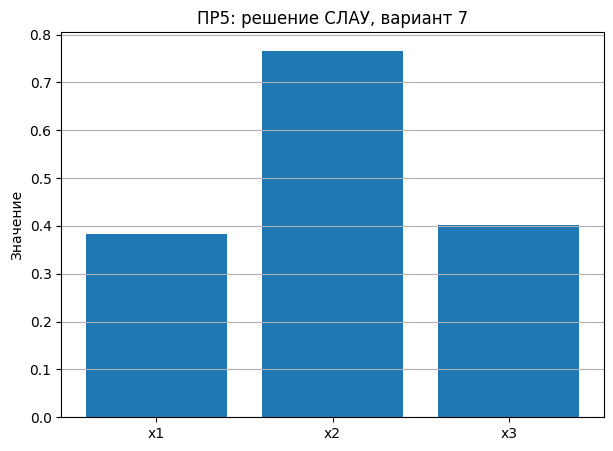

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Практическая работа №5
# Вариант 7
# Решение СЛАУ методом Гаусса

A_original = np.array([
    [0.20,  0.44, 0.81],
    [0.58, -0.29, 0.05],
    [0.05,  0.34, 0.10]
], dtype=float)

B_original = np.array([0.74, 0.02, 0.32], dtype=float)


def gauss(A, B):
    A = A.copy().astype(float)
    B = B.copy().astype(float)
    n = len(B)
    sign = 1

    # прямой ход с выбором главного элемента
    for i in range(n):
        max_row = i + np.argmax(np.abs(A[i:, i]))
        if abs(A[max_row, i]) < 1e-15:
            raise ValueError("Матрица вырождена.")

        if max_row != i:
            A[[i, max_row]] = A[[max_row, i]]
            B[[i, max_row]] = B[[max_row, i]]
            sign *= -1

        for j in range(i + 1, n):
            factor = A[j, i] / A[i, i]
            A[j, i:] -= factor * A[i, i:]
            B[j] -= factor * B[i]

    # обратный ход
    X = np.zeros(n)
    for i in range(n - 1, -1, -1):
        X[i] = (B[i] - np.dot(A[i, i+1:], X[i+1:])) / A[i, i]

    determinant = sign * np.prod(np.diag(A))
    return X, determinant


X, det_A = gauss(A_original, B_original)
residual = A_original @ X - B_original
A_inv = np.linalg.inv(A_original)

print("Практическая работа №5, вариант 7")
print("Метод Гаусса")
print(f"x1 = {X[0]:.6f}")
print(f"x2 = {X[1]:.6f}")
print(f"x3 = {X[2]:.6f}")
print(f"\nОпределитель det(A) = {det_A:.6f}")

print("\nНевязки A*x - b:")
for i, r in enumerate(residual, start=1):
    print(f"ε{i} = {r:.10f}")

print("\nОбратная матрица A^-1:")
print(np.round(A_inv, 6))

# график решения
plt.figure(figsize=(7, 5))
plt.bar(["x1", "x2", "x3"], X)
plt.ylabel("Значение")
plt.title("ПР5: решение СЛАУ, вариант 7")
plt.grid(True, axis="y")
plt.savefig("pr5_variant7.png", dpi=150)
plt.show()
plt.close()
